# Figures for 2026-05-21 progress report

Each cell produces one figure file under `./figures/`. Names match the placeholders in `report.md`.

Workload: `specbench` (default) — change `WORKLOAD` to regenerate for `bfcl_v4`.

In [1]:
import json, re, os
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORKLOAD = 'specbench'
EXP = Path('/workspace/simulation/results/explorations') if Path('/workspace').exists() \
      else Path('/home/muchwater/advance-spec/simulation/results/explorations')
OUT = Path('./figures')
OUT.mkdir(exist_ok=True)

PATTERNS = {
    'extension':              (re.compile(r'^extension_f([\d.]+)_t([\d.]+)$'),                            ['F','T']),
    'extension_oracle':       (re.compile(r'^extension_oracle_f([\d.]+)_t([\d.]+)$'),                     ['F','T']),
    'extension_by_score':     (re.compile(r'^extension_by_score_t([\d.]+)_f([\d.]+)_t([\d.]+)$'),         ['score','F','T']),
    'extension_by_pt_alpha':  (re.compile(r'^extension_by_pt_alpha_a([\d.]+)_t([\d.]+)_f([\d.]+)_t([\d.]+)$'), ['alpha','pt','F','T']),
    'extension_by_combined':  (re.compile(r'^extension_by_combined_a([\d.]+)_pt([\d.]+)_s([\d.]+)_f([\d.]+)_t([\d.]+)$'), ['alpha','pt','score','F','T']),
    'extension_by_product':   (re.compile(r'^extension_by_product_a([\d.]+)_t([\d.]+)_f([\d.]+)_t([\d.]+)$'),  ['alpha','threshold','F','T']),
}

def collect_rows(wl):
    rows = []
    for fp in sorted(EXP.glob(f'sim_{wl}_s*_full.json')):
        m_sk = re.match(rf'sim_{wl}_s(\d+)k(\d+)_full', fp.stem)
        if not m_sk: continue
        s, k = int(m_sk.group(1)), int(m_sk.group(2))
        with open(fp) as f: d = json.load(f)
        df = pd.DataFrame(d['latency']['budget_sweep'])
        for col in df.columns:
            if not col.endswith('_speedup_real'): continue
            raw = col[:-len('_speedup_real')]
            for fam, (rx, keys) in PATTERNS.items():
                m = rx.match(raw)
                if m:
                    params = {kk: float(vv) for kk, vv in zip(keys, m.groups())}
                    mat_col = f'{raw}_mat'
                    for idx in df.index:
                        v = df[col].iloc[idx]
                        if pd.notna(v):
                            rows.append({'fam': fam, 'cfg': raw, 's': s, 'k': k,
                                         'B': int(df['budget'].iloc[idx]),
                                         'spd': float(v),
                                         'mat': float(df[mat_col].iloc[idx]) if mat_col in df.columns else np.nan,
                                         **{f'p_{kk}': vv for kk, vv in params.items()}})
                    break
    return pd.DataFrame(rows)

df_main = collect_rows(WORKLOAD)
print(f'{WORKLOAD}: {len(df_main)} rows across {df_main["fam"].nunique()} families')

# Family display labels
FAM_LABEL = {
    'extension': 'Basic',
    'extension_by_score': 'by_score',
    'extension_by_pt_alpha': 'by_pt_alpha',
    'extension_by_combined': 'by_combined (AND)',
    'extension_by_product': 'by_product (mult)',
    'extension_oracle': 'Oracle',
}
FAM_COLOR = {
    'extension': '#888',
    'extension_by_score': '#5b9bd5',
    'extension_by_pt_alpha': '#a5a5a5',
    'extension_by_combined': '#ed7d31',
    'extension_by_product': '#70ad47',
    'extension_oracle': '#c00000',
}

specbench: 31398 rows across 6 families


## fig1 — Method comparison (best per family)

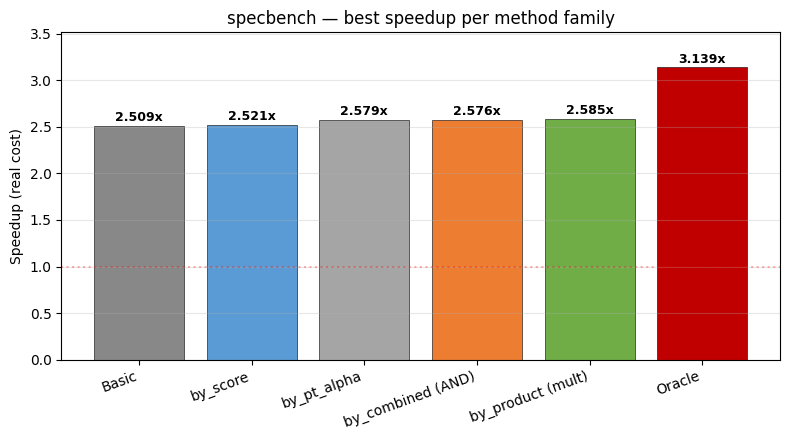

In [2]:
best_per_fam = (df_main.sort_values('spd', ascending=False)
                .drop_duplicates(subset='fam').reset_index(drop=True))
order = ['extension','extension_by_score','extension_by_pt_alpha',
         'extension_by_combined','extension_by_product','extension_oracle']
best_per_fam = best_per_fam.set_index('fam').loc[[f for f in order if f in best_per_fam['fam'].tolist() or f in best_per_fam.index]].reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(best_per_fam))
ax.bar(x, best_per_fam['spd'],
       color=[FAM_COLOR.get(f, '#999') for f in best_per_fam['fam']],
       edgecolor='black', linewidth=0.4)
for i, r in best_per_fam.iterrows():
    ax.text(i, r['spd']+0.02, f"{r['spd']:.3f}x", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABEL.get(f, f) for f in best_per_fam['fam']], rotation=20, ha='right')
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WORKLOAD} — best speedup per method family')
ax.axhline(1.0, color='red', linestyle=':', alpha=0.3)
ax.set_ylim(top=best_per_fam['spd'].max()*1.12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'fig1_method_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## fig2 — Per-budget curve: basic explodes, oracle scales, by_product caps

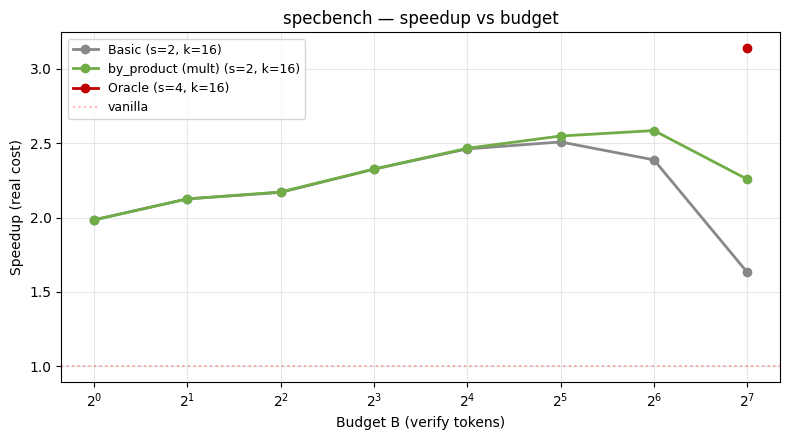

In [3]:
# Best (s, k) for each family
sk_per_fam = (df_main.sort_values('spd', ascending=False)
              .drop_duplicates(subset='fam')[['fam','s','k']].set_index('fam'))

fams_show = ['extension','extension_by_product','extension_oracle']
fig, ax = plt.subplots(figsize=(8, 4.5))
for fam in fams_show:
    if fam not in sk_per_fam.index: continue
    s, k = int(sk_per_fam.loc[fam, 's']), int(sk_per_fam.loc[fam, 'k'])
    sub = df_main[(df_main['fam']==fam) & (df_main['s']==s) & (df_main['k']==k)]
    # Best spd per B (max over hp)
    curve = sub.groupby('B')['spd'].max().sort_index()
    ax.plot(curve.index, curve.values, marker='o',
            label=f'{FAM_LABEL[fam]} (s={s}, k={k})',
            color=FAM_COLOR.get(fam,'#999'), linewidth=2)
ax.axhline(1.0, color='red', linestyle=':', alpha=0.3, label='vanilla')
ax.set_xscale('log', base=2)
ax.set_xlabel('Budget B (verify tokens)')
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WORKLOAD} — speedup vs budget')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'fig2_per_budget_curve.png', dpi=140, bbox_inches='tight')
plt.show()

## fig3 — First filters fail

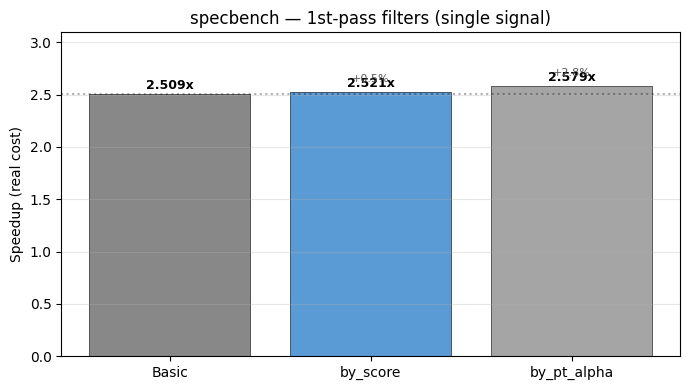

In [4]:
fams_show = ['extension','extension_by_score','extension_by_pt_alpha']
sub = best_per_fam[best_per_fam['fam'].isin(fams_show)].set_index('fam').loc[fams_show].reset_index()
basic_spd = sub[sub['fam']=='extension']['spd'].iloc[0]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(sub))
colors = [FAM_COLOR.get(f, '#999') for f in sub['fam']]
ax.bar(x, sub['spd'], color=colors, edgecolor='black', linewidth=0.4)
for i, r in sub.iterrows():
    gain = (r['spd']-basic_spd)/basic_spd*100
    ax.text(i, r['spd']+0.02, f"{r['spd']:.3f}x", ha='center', va='bottom', fontsize=9, fontweight='bold')
    if r['fam'] != 'extension':
        ax.text(i, r['spd']+0.08, f"{gain:+.1f}%", ha='center', va='bottom', fontsize=8, color='#555')
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABEL[f] for f in sub['fam']])
ax.axhline(basic_spd, color='black', linestyle=':', alpha=0.3, label='basic')
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WORKLOAD} — 1st-pass filters (single signal)')
ax.set_ylim(top=sub['spd'].max()*1.20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'fig3_first_filters.png', dpi=140, bbox_inches='tight')
plt.show()

## fig4 — Precision/recall trade-off (filter strictness)

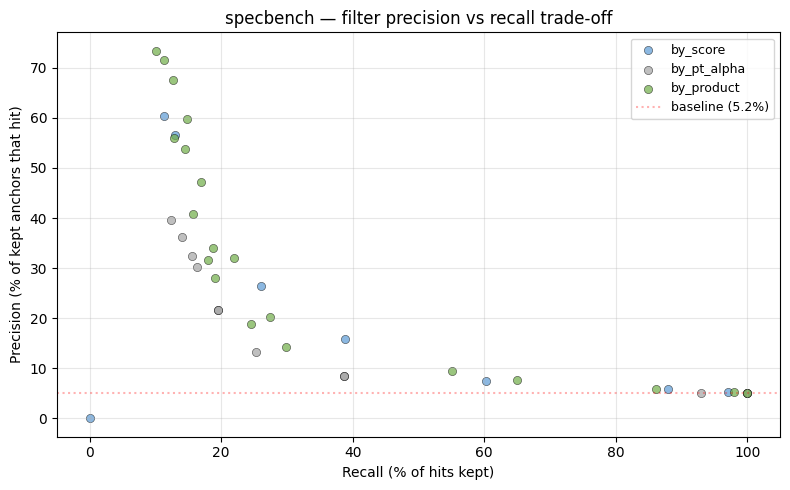

In [5]:
# Compute precision/recall from trace data
TRACE = Path(str(EXP / f'trace_accepted_14b_{WORKLOAD}_maxtree.json'))
with open(TRACE) as f: td = json.load(f)
anchors = pd.concat([pd.DataFrame(td['raw']['considered_root']),
                     pd.DataFrame(td['raw']['considered_pernode'])], ignore_index=True)
anchors['hit'] = anchors['gt_match_length'] > 0
total_hits = anchors['hit'].sum()

def pr(mask, name):
    n_pass = mask.sum()
    h_pass = anchors.loc[mask,'hit'].sum()
    return {'name': name,
            'pass_rate': n_pass/len(anchors),
            'precision': h_pass/n_pass if n_pass else 0,
            'recall': h_pass/total_hits if total_hits else 0}

configs = []
for thr in [0.5, 1, 2, 3, 5, 10, 15, 20]:
    configs.append({**pr(anchors['score']>=thr, f'by_score thr={thr}'), 'family':'by_score'})
for a in [0.5, 1, 2]:
    for thr in [0.001, 0.01, 0.1, 0.5]:
        configs.append({**pr(anchors['path_p_t']**a >= thr, f'by_pt_alpha α={a} t={thr}'), 'family':'by_pt_alpha'})
for a in [0.25, 0.5, 1, 2]:
    for thr in [0.05, 0.1, 0.5, 2, 5]:
        configs.append({**pr(anchors['score']*anchors['path_p_t']**a >= thr, f'by_product α={a} t={thr}'), 'family':'by_product'})

pr_df = pd.DataFrame(configs)
fam_color = {'by_score':'#5b9bd5','by_pt_alpha':'#a5a5a5','by_product':'#70ad47'}
fig, ax = plt.subplots(figsize=(8, 5))
for fam in ['by_score','by_pt_alpha','by_product']:
    sub = pr_df[pr_df['family']==fam]
    ax.scatter(sub['recall']*100, sub['precision']*100, s=35, alpha=0.7,
               color=fam_color[fam], label=fam, edgecolor='black', linewidth=0.4)
ax.axhline(total_hits/len(anchors)*100, color='red', linestyle=':', alpha=0.3,
           label=f'baseline ({total_hits/len(anchors)*100:.1f}%)')
ax.set_xlabel('Recall (% of hits kept)')
ax.set_ylabel('Precision (% of kept anchors that hit)')
ax.set_title(f'{WORKLOAD} — filter precision vs recall trade-off')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'fig4_precision_recall_curve.png', dpi=140, bbox_inches='tight')
plt.show()

## fig5 — Second filters (joint signal) marginal improvement

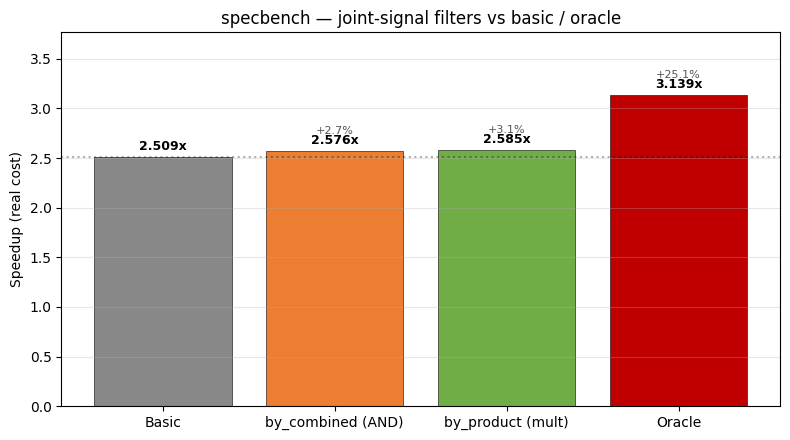

In [6]:
fams_show = ['extension','extension_by_combined','extension_by_product','extension_oracle']
sub = best_per_fam[best_per_fam['fam'].isin(fams_show)].set_index('fam').loc[fams_show].reset_index()
basic_spd = sub[sub['fam']=='extension']['spd'].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(sub))
colors = [FAM_COLOR.get(f, '#999') for f in sub['fam']]
ax.bar(x, sub['spd'], color=colors, edgecolor='black', linewidth=0.4)
for i, r in sub.iterrows():
    gain = (r['spd']-basic_spd)/basic_spd*100
    ax.text(i, r['spd']+0.04, f"{r['spd']:.3f}x", ha='center', va='bottom', fontsize=9, fontweight='bold')
    if r['fam'] != 'extension':
        ax.text(i, r['spd']+0.15, f"{gain:+.1f}%", ha='center', va='bottom', fontsize=8, color='#555')
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABEL[f] for f in sub['fam']])
ax.axhline(basic_spd, color='black', linestyle=':', alpha=0.3, label='basic')
ax.set_ylabel('Speedup (real cost)')
ax.set_title(f'{WORKLOAD} — joint-signal filters vs basic / oracle')
ax.set_ylim(top=sub['spd'].max()*1.20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT/'fig5_second_filters.png', dpi=140, bbox_inches='tight')
plt.show()

## fig6 — Joint (score × path_p_t) hit-rate heatmap

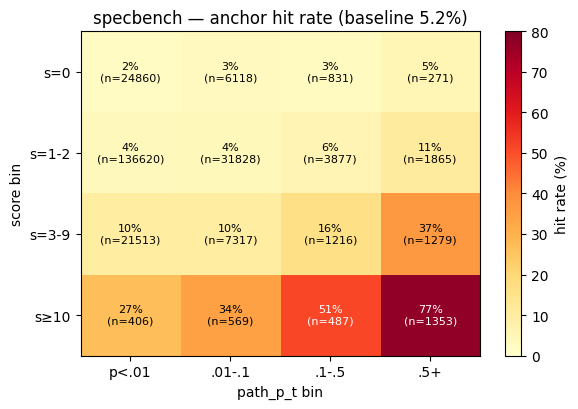

In [7]:
anchors['s_b'] = pd.cut(anchors['score'], bins=[-0.001, 0.5, 2.5, 10, 1000], labels=['s=0','s=1-2','s=3-9','s≥10'])
anchors['p_b'] = pd.cut(anchors['path_p_t'], bins=[0, 0.01, 0.1, 0.5, 1.001], labels=['p<.01','.01-.1','.1-.5','.5+'])
j = anchors.groupby(['s_b','p_b'], observed=True).agg(n=('hit','size'), hits=('hit','sum')).reset_index()
j['rate'] = j['hits']/j['n']*100
pv = j.pivot_table(index='s_b', columns='p_b', values='rate', observed=True)
pv_n = j.pivot_table(index='s_b', columns='p_b', values='n', observed=True)

fig, ax = plt.subplots(figsize=(6, 4.2))
im = ax.imshow(pv.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=80)
for i in range(pv.shape[0]):
    for j_idx in range(pv.shape[1]):
        v = pv.values[i, j_idx]
        n = pv_n.values[i, j_idx]
        text_color = 'white' if v > 40 else 'black'
        ax.text(j_idx, i, f'{v:.0f}%\n(n={int(n)})', ha='center', va='center',
                fontsize=8, color=text_color)
ax.set_xticks(range(len(pv.columns)))
ax.set_xticklabels(pv.columns)
ax.set_yticks(range(len(pv.index)))
ax.set_yticklabels(pv.index)
ax.set_xlabel('path_p_t bin')
ax.set_ylabel('score bin')
ax.set_title(f'{WORKLOAD} — anchor hit rate (baseline {total_hits/len(anchors)*100:.1f}%)')
plt.colorbar(im, ax=ax, label='hit rate (%)')
plt.tight_layout()
plt.savefig(OUT/'fig6_joint_hit_rate_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()

## fig7 — Budget breakdown (per-method, backbone vs extension waste)

Requires breakdown collection (autotriggered after current batch). Output files: `_tmp_breakdown/14b/sim_{wl}_s{s}k{k}_breakdown.json`.

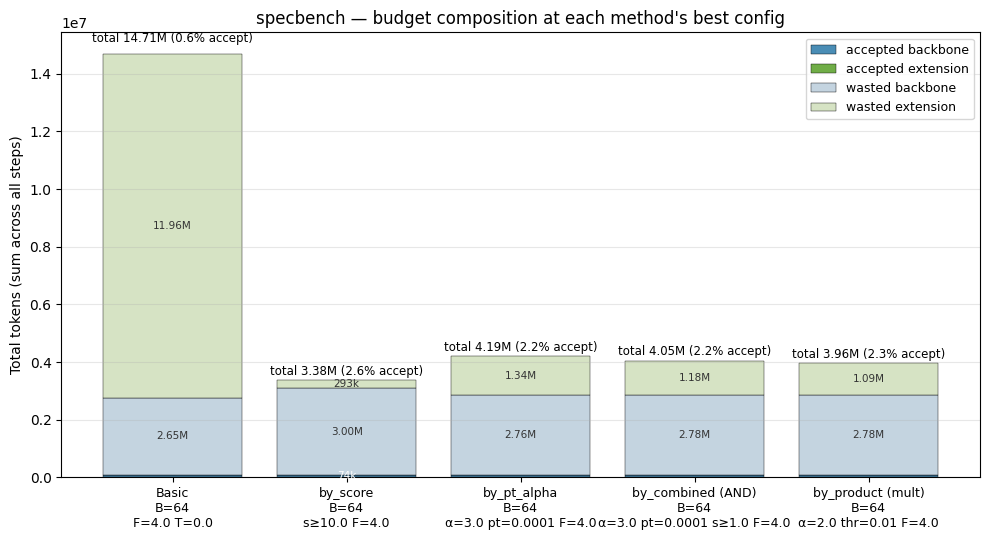

In [8]:
BD_DIR = Path('/workspace/simulation/results/_tmp_breakdown/14b') if Path('/workspace').exists() \
         else Path('/home/muchwater/advance-spec/simulation/results/_tmp_breakdown/14b')

bd_fp = BD_DIR / f'sim_{WORKLOAD}_s2k16_breakdown.json'
if not bd_fp.exists():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.text(0.5, 0.5, '(placeholder)\nBreakdown data not yet available',
            ha='center', va='center', fontsize=14, color='#666', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{WORKLOAD} — budget breakdown (TBD)')
    plt.tight_layout()
    plt.savefig(OUT/'fig7_budget_breakdown.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    bd = json.load(open(bd_fp))
    bd_df = pd.DataFrame(bd['latency']['budget_sweep']).set_index('budget')

    # Best B per method (matching what we picked for breakdown sim)
    # Pull from canonical to identify best B for each method
    # Fixed B=64 for ALL methods (unified comparison).
    # Pick best hp per family among configs that actually have breakdown data
    # (intersect canonical with bd_df breakdown columns).
    FIXED_B = 64
    df_main_t0 = df_main[df_main['cfg'].str.contains('_t0.0', regex=False)] if not df_main.empty else df_main
    cfgs_with_bd = {c[:-len('_bd_base_size')] for c in bd_df.columns if c.endswith('_bd_base_size')}
    best_per_method = {}
    for fam in PATTERNS:
        sub = df_main_t0[df_main_t0['fam']==fam]
        sub = sub[sub['B'] == FIXED_B]
        sub = sub[sub['cfg'].isin(cfgs_with_bd)]
        if sub.empty: continue
        top = sub.sort_values('spd', ascending=False).iloc[0]
        best_per_method[fam] = (top['cfg'], FIXED_B)

    # Build chart
    order = ['extension','extension_by_score','extension_by_pt_alpha','extension_by_combined','extension_by_product']
    fam_ordered = [f for f in order if f in best_per_method]
    n = len(fam_ordered)
    if n == 0:
        print('No matching methods in breakdown data')
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(n)
    ab_list = []; as_list = []; wb_list = []; ws_list = []
    labels = []
    for fam in fam_ordered:
        cfg, B = best_per_method[fam]
        ab_list.append(int(bd_df[f'{cfg}_bd_accepted_base'].loc[B]))
        as_list.append(int(bd_df[f'{cfg}_bd_accepted_suffix'].loc[B]))
        wb_list.append(int(bd_df[f'{cfg}_bd_wasted_base'].loc[B]))
        ws_list.append(int(bd_df[f'{cfg}_bd_wasted_suffix'].loc[B]))
        # Compact hp string for this config
        import re as _re_lbl
        if fam == 'extension':
            _m = _re_lbl.search(r'_f([\d.]+)_t([\d.]+)$', cfg); _hp = f'F={_m.group(1)} T={_m.group(2)}' if _m else ''
        elif fam == 'extension_by_score':
            _m = _re_lbl.match(r'extension_by_score_t([\d.]+)_f([\d.]+)_t([\d.]+)', cfg); _hp = f's≥{_m.group(1)} F={_m.group(2)}' if _m else ''
        elif fam == 'extension_by_pt_alpha':
            _m = _re_lbl.match(r'extension_by_pt_alpha_a([\d.]+)_t([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} pt={_m.group(2)} F={_m.group(3)}' if _m else ''
        elif fam == 'extension_by_combined':
            _m = _re_lbl.match(r'extension_by_combined_a([\d.]+)_pt([\d.]+)_s([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} pt={_m.group(2)} s≥{_m.group(3)} F={_m.group(4)}' if _m else ''
        elif fam == 'extension_by_product':
            _m = _re_lbl.match(r'extension_by_product_a([\d.]+)_t([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} thr={_m.group(2)} F={_m.group(3)}' if _m else ''
        else:
            _hp = ''
        labels.append(f'{FAM_LABEL[fam]}\nB={B}\n{_hp}')

    ab = np.array(ab_list); as_ = np.array(as_list); wb = np.array(wb_list); ws_ = np.array(ws_list)
    ax.bar(x, ab, color='#4a8db5', label='accepted backbone', edgecolor='black', linewidth=0.3)
    ax.bar(x, as_, bottom=ab, color='#70ad47', label='accepted extension', edgecolor='black', linewidth=0.3)
    ax.bar(x, wb, bottom=ab+as_, color='#c4d4e0', label='wasted backbone', edgecolor='black', linewidth=0.3)
    ax.bar(x, ws_, bottom=ab+as_+wb, color='#d6e3c4', label='wasted extension', edgecolor='black', linewidth=0.3)

    # Annotate accept % per method
    totals = ab + as_ + wb + ws_
    def _fmt(v):
        if v >= 1_000_000: return f'{v/1_000_000:.2f}M'
        if v >= 1_000: return f'{v/1_000:.0f}k'
        return f'{v}'
    for i in range(n):
        # Per-segment count annotations (centered in each stacked block)
        y0 = 0
        for seg_val, color in [(ab[i], 'white'), (as_[i], 'white'),
                                (wb[i], '#333'), (ws_[i], '#333')]:
            if seg_val > totals[i] * 0.02:  # only annotate visible segments
                ax.text(i, y0 + seg_val/2, _fmt(int(seg_val)),
                        ha='center', va='center', fontsize=7.5, color=color)
            y0 += seg_val
        # Top label with totals + accept rate
        ax.text(i, totals[i]*1.02,
                f'total {_fmt(int(totals[i]))} ({(ab[i]+as_[i])/totals[i]*100:.1f}% accept)',
                ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Total tokens (sum across all steps)')
    ax.set_title(f'{WORKLOAD} — budget composition at each method\'s best config')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT/'fig7_budget_breakdown.png', dpi=140, bbox_inches='tight')
    plt.show()


## fig7b — Budget breakdown for bfcl_v4 (parallel to fig7)

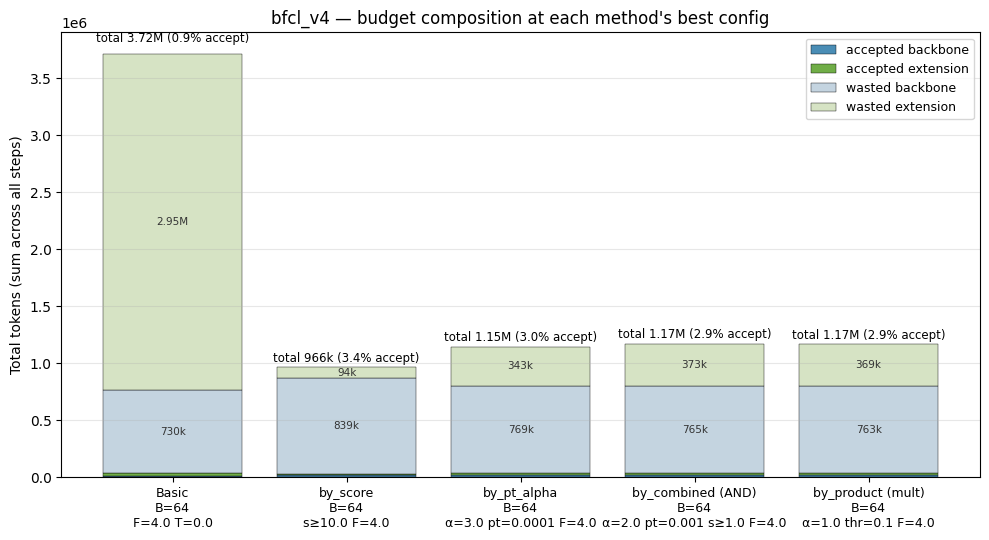

In [9]:
# Render the same budget-breakdown chart but for bfcl_v4.
# Reuses PATTERNS / FAM_LABEL / FAM_COLOR / OUT from earlier cells.
_WL_BFCL = 'bfcl_v4'
bd_fp_b = (Path('/workspace/simulation/results/_tmp_breakdown/14b') if Path('/workspace').exists()
           else Path('/home/muchwater/advance-spec/simulation/results/_tmp_breakdown/14b')) / f'sim_{_WL_BFCL}_s2k16_breakdown.json'
df_bfcl = collect_rows(_WL_BFCL)
if not bd_fp_b.exists():
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.text(0.5, 0.5, '(placeholder)\nBreakdown data not yet available',
            ha='center', va='center', fontsize=14, color='#666', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{_WL_BFCL} — budget breakdown (TBD)')
    plt.tight_layout()
    plt.savefig(OUT/'fig7b_budget_breakdown_bfcl.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    bd = json.load(open(bd_fp_b))
    bd_df = pd.DataFrame(bd['latency']['budget_sweep']).set_index('budget')

    # Filter to enrollable (T=0.0) configs in canonical to match breakdown sim.
    df_bfcl_t0 = df_bfcl[df_bfcl['cfg'].str.contains('_t0.0', regex=False)] if not df_bfcl.empty else df_bfcl
    # Fixed B=64 for ALL methods (unified comparison).
    # Pick best hp per family among configs with breakdown data.
    FIXED_B = 64
    cfgs_with_bd = {c[:-len('_bd_base_size')] for c in bd_df.columns if c.endswith('_bd_base_size')}
    best_per_method = {}
    for fam in PATTERNS:
        sub = df_bfcl_t0[df_bfcl_t0['fam']==fam]
        sub = sub[sub['B'] == FIXED_B]
        sub = sub[sub['cfg'].isin(cfgs_with_bd)]
        if sub.empty: continue
        top = sub.sort_values('spd', ascending=False).iloc[0]
        best_per_method[fam] = (top['cfg'], FIXED_B)

    order = ['extension','extension_by_score','extension_by_pt_alpha','extension_by_combined','extension_by_product']
    fam_ordered = [f for f in order if f in best_per_method]
    n = len(fam_ordered)
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(n)
    ab_list = []; as_list = []; wb_list = []; ws_list = []; labels = []
    for fam in fam_ordered:
        cfg, B = best_per_method[fam]
        ab_list.append(int(bd_df[f'{cfg}_bd_accepted_base'].loc[B]))
        as_list.append(int(bd_df[f'{cfg}_bd_accepted_suffix'].loc[B]))
        wb_list.append(int(bd_df[f'{cfg}_bd_wasted_base'].loc[B]))
        ws_list.append(int(bd_df[f'{cfg}_bd_wasted_suffix'].loc[B]))
        # Compact hp string for this config
        import re as _re_lbl
        if fam == 'extension':
            _m = _re_lbl.search(r'_f([\d.]+)_t([\d.]+)$', cfg); _hp = f'F={_m.group(1)} T={_m.group(2)}' if _m else ''
        elif fam == 'extension_by_score':
            _m = _re_lbl.match(r'extension_by_score_t([\d.]+)_f([\d.]+)_t([\d.]+)', cfg); _hp = f's≥{_m.group(1)} F={_m.group(2)}' if _m else ''
        elif fam == 'extension_by_pt_alpha':
            _m = _re_lbl.match(r'extension_by_pt_alpha_a([\d.]+)_t([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} pt={_m.group(2)} F={_m.group(3)}' if _m else ''
        elif fam == 'extension_by_combined':
            _m = _re_lbl.match(r'extension_by_combined_a([\d.]+)_pt([\d.]+)_s([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} pt={_m.group(2)} s≥{_m.group(3)} F={_m.group(4)}' if _m else ''
        elif fam == 'extension_by_product':
            _m = _re_lbl.match(r'extension_by_product_a([\d.]+)_t([\d.]+)_f([\d.]+)', cfg); _hp = f'α={_m.group(1)} thr={_m.group(2)} F={_m.group(3)}' if _m else ''
        else:
            _hp = ''
        labels.append(f'{FAM_LABEL[fam]}\nB={B}\n{_hp}')

    ab = np.array(ab_list); as_ = np.array(as_list); wb = np.array(wb_list); ws_ = np.array(ws_list)
    ax.bar(x, ab, color='#4a8db5', label='accepted backbone', edgecolor='black', linewidth=0.3)
    ax.bar(x, as_, bottom=ab, color='#70ad47', label='accepted extension', edgecolor='black', linewidth=0.3)
    ax.bar(x, wb, bottom=ab+as_, color='#c4d4e0', label='wasted backbone', edgecolor='black', linewidth=0.3)
    ax.bar(x, ws_, bottom=ab+as_+wb, color='#d6e3c4', label='wasted extension', edgecolor='black', linewidth=0.3)

    totals = ab + as_ + wb + ws_
    def _fmt(v):
        if v >= 1_000_000: return f'{v/1_000_000:.2f}M'
        if v >= 1_000: return f'{v/1_000:.0f}k'
        return f'{v}'
    for i in range(n):
        # Per-segment count annotations (centered in each stacked block)
        y0 = 0
        for seg_val, color in [(ab[i], 'white'), (as_[i], 'white'),
                                (wb[i], '#333'), (ws_[i], '#333')]:
            if seg_val > totals[i] * 0.02:  # only annotate visible segments
                ax.text(i, y0 + seg_val/2, _fmt(int(seg_val)),
                        ha='center', va='center', fontsize=7.5, color=color)
            y0 += seg_val
        # Top label with totals + accept rate
        ax.text(i, totals[i]*1.02,
                f'total {_fmt(int(totals[i]))} ({(ab[i]+as_[i])/totals[i]*100:.1f}% accept)',
                ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Total tokens (sum across all steps)')
    ax.set_title(f"{_WL_BFCL} — budget composition at each method's best config")
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT/'fig7b_budget_breakdown_bfcl.png', dpi=140, bbox_inches='tight')
    plt.show()


## fig8 — Decision tree (next direction)

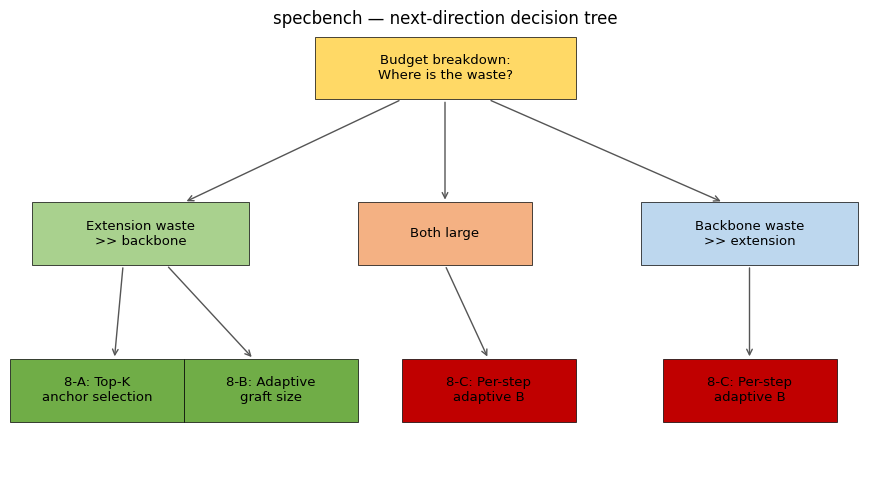

In [10]:
# Text-based decision tree diagram.
fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')

boxes = [
    (0.5, 0.92, 'Budget breakdown:\nWhere is the waste?', '#ffd966', 0.30),
    (0.15, 0.55, 'Extension waste\n>> backbone', '#a9d18e', 0.25),
    (0.50, 0.55, 'Both large', '#f4b183', 0.20),
    (0.85, 0.55, 'Backbone waste\n>> extension', '#bdd7ee', 0.25),
    (0.10, 0.20, '8-A: Top-K\nanchor selection', '#70ad47', 0.20),
    (0.30, 0.20, '8-B: Adaptive\ngraft size', '#70ad47', 0.20),
    (0.55, 0.20, '8-C: Per-step\nadaptive B', '#c00000', 0.20),
    (0.85, 0.20, '8-C: Per-step\nadaptive B', '#c00000', 0.20),
]
for x, y, txt, color, w in boxes:
    ax.add_patch(plt.Rectangle((x-w/2, y-0.07), w, 0.14, facecolor=color, edgecolor='black', linewidth=0.5))
    ax.text(x, y, txt, ha='center', va='center', fontsize=9.5)

# Arrows: top → 3 branches → outcomes
def arrow(x1,y1,x2,y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1), arrowprops=dict(arrowstyle='->', lw=1, color='#555'))
arrow(0.45, 0.85, 0.20, 0.62)  # ext branch
arrow(0.50, 0.85, 0.50, 0.62)  # both branch
arrow(0.55, 0.85, 0.82, 0.62)  # backbone branch
arrow(0.13, 0.48, 0.12, 0.27)  # ext → top-K
arrow(0.18, 0.48, 0.28, 0.27)  # ext → adaptive graft
arrow(0.50, 0.48, 0.55, 0.27)  # both → per-step
arrow(0.85, 0.48, 0.85, 0.27)  # backbone → per-step

ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f'{WORKLOAD} — next-direction decision tree')
plt.tight_layout()
plt.savefig(OUT/'fig8_decision_tree.png', dpi=140, bbox_inches='tight')
plt.show()